# The frequency/cost frontier: does trading faster ever pay at €1,000?

Seventh notebook. The previous six tested *what* to trade. This one tests *how
often*, which at retail size turns out to be the more binding question.

The Crypto.com connector plugged into this session returns only 50 candles per
request with no paging — 50 minutes of 1-minute history — so it cannot support
a backtest. It did answer a different question usefully: a live BTC order-book
snapshot showed a **one-cent spread** (78,558.94 bid / 78,558.95 ask) with
enough size at the top of book to fill €1,000 outright. So at this size,
slippage and market impact are ~zero on a major pair. **The entire cost of
trading is the exchange fee**, and that scales linearly with how often you
trade.

The data here instead comes from **Binance's public archives**
(`data.binance.vision`), which publish complete 1-minute OHLCV back to 2017.
The Binance REST API is geo-blocked from this host; the static archives are not.

## The question

At what holding period does fee drag stop eating everything — and does any
signal survive at that frequency?

## Criteria, fixed before running anything

| # | Criterion | Threshold |
|---|---|---|
| F1 | Some (signal, holding period) is net-positive in the design period | net return > 0 after fees |
| F2 | It beats the bootstrap null | above the 95th pct of max-stat on return-shuffled paths |
| F3 | It survives the holdout | same sign, design 2017-2023 → holdout 2024-2026 |
| F4 | It beats simply holding BTC | higher net Sharpe than buy-and-hold, same window |
| F5 | It is executable by hand at €1,000 | no sub-minute latency, tolerable trade count |

**Design 2017-08 → 2023-12. Holdout 2024-01 → 2026-08.**

In [1]:
from __future__ import annotations

import warnings
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

warnings.filterwarnings("ignore", category=RuntimeWarning)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = REPO / "data" / "crypto_intraday"

SURFACE, INK, INK_2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#dcdcd7"
C1, C2, C3, C4 = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.linewidth": 0.8, "axes.labelcolor": INK_2,
    "axes.titlecolor": INK, "axes.titlesize": 10.5, "axes.titleweight": "bold",
    "axes.titlelocation": "left", "axes.titlepad": 9, "axes.grid": True,
    "axes.spines.top": False, "axes.spines.right": False,
    "grid.color": GRID, "grid.linewidth": 0.7, "xtick.color": INK_2, "ytick.color": INK_2,
    "xtick.labelsize": 9, "ytick.labelsize": 9, "text.color": INK, "font.size": 10,
    "legend.frameon": False, "legend.fontsize": 9, "lines.linewidth": 1.8, "figure.dpi": 110,
})


def figure_titles(fig, title, subtitle, top=0.88):
    fig.suptitle(title, x=0.008, y=0.985, ha="left", va="top",
                 fontsize=12.5, weight="bold", color=INK)
    fig.text(0.008, 0.925, subtitle, ha="left", va="top", fontsize=9.5, color=INK_2)
    fig.tight_layout(rect=(0, 0, 1, top))


DESIGN_END = pd.Timestamp("2024-01-01")
MIN_PER_YEAR = 365 * 24 * 60
# Holding periods, in minutes
HOLDS = [1, 5, 15, 30, 60, 240, 720, 1440, 4320, 10080]
HOLD_LABEL = {1: "1m", 5: "5m", 15: "15m", 30: "30m", 60: "1h", 240: "4h",
              720: "12h", 1440: "1d", 4320: "3d", 10080: "1w"}
# Round-trip cost in basis points. Crypto.com Exchange taker is tier-dependent;
# 15bp round trip is a good retail tier, 50bp a poor one. The connector snapshot
# says spread adds ~0 on BTC at this size, so this is essentially all fee.
COST_BPS = 30.0

## 1. Data

In [2]:
def load(symbol: str) -> pd.DataFrame:
    df = pd.read_parquet(DATA / f"{symbol}_1m.parquet")
    return df.set_index("ts").sort_index()


BTC = load("BTCUSDT")
print(f"BTCUSDT  {len(BTC):,} 1-minute bars   {BTC.index[0]} -> {BTC.index[-1]}")
print(f"         {(BTC.index[-1]-BTC.index[0]).days/365.25:.1f} years")
gaps = (BTC.index.to_series().diff().dt.total_seconds().fillna(60) != 60).sum()
print(f"         {gaps:,} gaps ({gaps/len(BTC)*100:.3f}% of bars)")
try:
    ETH = load("ETHUSDT")
    print(f"ETHUSDT  {len(ETH):,} bars   {ETH.index[0]} -> {ETH.index[-1]}")
except FileNotFoundError:
    ETH = None
    print("ETHUSDT  not available")

BTCUSDT  4,754,719 1-minute bars   2017-08-17 04:00:00 -> 2026-09-06 23:59:00
         9.1 years


         35 gaps (0.001% of bars)


ETHUSDT  4,754,718 bars   2017-08-17 04:00:00 -> 2026-09-06 23:59:00


## 2. The arithmetic frontier — before any signal

This part needs no backtest and cannot be argued with. If you hold for `h`
minutes and flip position each time, you trade `525,600 / h` times a year, and
each round trip costs `c`. The annual drag is the product.

The order-book snapshot said spread and impact are ~zero for €1,000 of BTC, so
`c` here is essentially pure exchange fee.

In [3]:
rows = []
for h in HOLDS:
    tpy = MIN_PER_YEAR / h
    rows.append({"hold": HOLD_LABEL[h], "trades_per_year": tpy,
                 **{f"drag_@{c:.0f}bp": tpy * c / 1e4 * 100 for c in (15, 30, 50)}})
FRONTIER = pd.DataFrame(rows).set_index("hold")
print("ANNUAL COST DRAG (%/yr) IF YOU FLIP EVERY PERIOD\n")
print(FRONTIER.round(1).to_string())
print(f"""
  Read the bottom rows first. Holding a week and flipping every week costs
  {FRONTIER.loc['1w','drag_@30bp']:.1f}%/yr at a 30bp round trip. Holding a day costs {FRONTIER.loc['1d','drag_@30bp']:.0f}%/yr.
  Holding an hour costs {FRONTIER.loc['1h','drag_@30bp']:,.0f}%/yr. Anything faster is arithmetic nonsense
  at retail fees - you would need a gross edge larger than any documented
  anomaly in any asset class, just to break even.

  This is why the study below only has to look carefully at the slow end. The
  fast end is excluded by arithmetic, not by evidence.""")

ANNUAL COST DRAG (%/yr) IF YOU FLIP EVERY PERIOD

      trades_per_year  drag_@15bp  drag_@30bp  drag_@50bp
hold                                                     
1m        525,600.000  78,840.000 157,680.000 262,800.000
5m        105,120.000  15,768.000  31,536.000  52,560.000
15m        35,040.000   5,256.000  10,512.000  17,520.000
30m        17,520.000   2,628.000   5,256.000   8,760.000
1h          8,760.000   1,314.000   2,628.000   4,380.000
4h          2,190.000     328.500     657.000   1,095.000
12h           730.000     109.500     219.000     365.000
1d            365.000      54.800     109.500     182.500
3d            121.700      18.200      36.500      60.800
1w             52.100       7.800      15.600      26.100

  Read the bottom rows first. Holding a week and flipping every week costs
  15.6%/yr at a 30bp round trip. Holding a day costs 110%/yr.
  Holding an hour costs 2,628%/yr. Anything faster is arithmetic nonsense
  at retail fees - you would need a gross 

## 3. Signal battery across holding periods

For each holding period, the simplest and most-documented time-series signals:
**momentum** (long if the last `k` periods were up) and **reversal** (the
opposite), for several lookbacks. Long/short, so it is a pure directional bet
with no market exposure baked in.

Two disciplines carried over from earlier notebooks:

* **Phase averaging.** Notebook 1 showed a result can live or die on which day
  of the month you start. The same applies here to which minute you start a
  4-hour clock on, so every result is averaged over evenly-spaced phase offsets
  rather than reported for one arbitrary alignment.
* **Costs charged on realised turnover**, not assumed turnover — a signal that
  rarely flips is charged less.

In [4]:
LOOKBACKS = (1, 2, 4, 8, 16)


def series_log(df: pd.DataFrame, lo=None, hi=None) -> np.ndarray:
    s = df["close"]
    if lo is not None:
        s = s[s.index >= lo]
    if hi is not None:
        s = s[s.index < hi]
    return np.log(s.to_numpy(dtype="float64"))


def run_one(lp: np.ndarray, h: int, k: int, mode: str, cost_bps: float, offset: int):
    p = lp[offset::h]
    if p.size < 4 * k + 20:
        return None
    r = np.diff(p)
    sig = pd.Series(r).rolling(k).sum().to_numpy()
    pos = np.sign(sig)
    if mode == "rev":
        pos = -pos
    pos = np.nan_to_num(pos)
    fwd = r[1:]
    pos = pos[:-1]
    turn = np.abs(np.diff(pos, prepend=0.0))
    net = pos * fwd - turn * cost_bps / 1e4
    gross = pos * fwd
    ok = np.isfinite(net)
    if ok.sum() < 30:
        return None
    net, gross, turn = net[ok], gross[ok], turn[ok]
    ppy = MIN_PER_YEAR / h
    sd = net.std(ddof=1)
    return {"n": net.size, "gross_ann_%": gross.mean() * ppy * 100,
            "net_ann_%": net.mean() * ppy * 100,
            "cost_ann_%": (turn.mean() * cost_bps / 1e4) * ppy * 100,
            "turnover": turn.mean(),
            "sharpe_net": (net.mean() / sd * np.sqrt(ppy)) if sd > 0 else np.nan}


def sweep(lp: np.ndarray, cost_bps: float = COST_BPS, holds=HOLDS,
          lookbacks=LOOKBACKS, n_offsets: int = 8) -> pd.DataFrame:
    out = []
    for h in holds:
        offs = np.unique(np.linspace(0, h - 1, min(n_offsets, h)).astype(int))
        for k in lookbacks:
            for mode in ("mom", "rev"):
                res = [run_one(lp, h, k, mode, cost_bps, o) for o in offs]
                res = [r for r in res if r]
                if not res:
                    continue
                d = pd.DataFrame(res).mean()
                out.append({"hold": HOLD_LABEL[h], "hold_min": h, "lookback": k,
                            "mode": mode, **d.to_dict()})
    return pd.DataFrame(out)


lp_design = series_log(BTC, hi=DESIGN_END)
SW = sweep(lp_design)
print(f"BTC DESIGN PERIOD — {len(SW)} (holding period x lookback x direction) combinations\n")
best = SW.sort_values("net_ann_%", ascending=False)
print(best.head(12).round(2).to_string(index=False))
print(f"\n  combinations with positive NET return: {(SW['net_ann_%'] > 0).sum()} of {len(SW)}")
print(f"  best net: {SW['net_ann_%'].max():+.1f}%/yr   "
      f"({best.iloc[0]['mode']}, hold {best.iloc[0]['hold']}, lookback {best.iloc[0]['lookback']:.0f})")
print(f"  median net across all combinations: {SW['net_ann_%'].median():+.1f}%/yr")

BTC DESIGN PERIOD — 100 (holding period x lookback x direction) combinations

hold  hold_min  lookback mode         n  gross_ann_%  net_ann_%  cost_ann_%  turnover  sharpe_net
  3d      4320         8  mom   771.880       63.020     52.250      10.770     0.300       0.710
  1w     10080         4  mom   329.620       56.670     50.370       6.300     0.400       0.680
  3d      4320        16  mom   771.880       54.190     46.720       7.470     0.200       0.640
  1w     10080         8  mom   329.620       46.360     41.970       4.390     0.280       0.580
  1w     10080         2  mom   329.620       49.140     39.460       9.680     0.620       0.530
  1d      1440        16  mom 2,319.880       47.940     23.490      24.450     0.220       0.320
  3d      4320         4  mom   771.880       38.900     22.610      16.290     0.450       0.310
  1w     10080        16  mom   329.620       23.200     20.000       3.200     0.200       0.290
  3d      4320         2  mom   771.880 

## 4. Bootstrap null (criterion F2)

The sweep tries 100 combinations. Across that many tries something will look
positive whether or not anything is there, so the same permutation discipline
applies as in notebooks 2 and 5: shuffle BTC's own 1-minute returns to destroy
all serial structure while preserving drift, volatility and fat tails, rebuild
a price path, and re-run the whole sweep on it.

The null is restricted to holding periods of **1 hour and slower**. The faster
ones are already excluded by the arithmetic in section 2 — no null is needed to
reject a strategy that must overcome five figures of annual fee drag.

In [5]:
NULL_HOLDS = [h for h in HOLDS if h >= 60]


def null_max(lp: np.ndarray, b: int = 300, cost_bps: float = COST_BPS, seed: int = 3):
    rng = np.random.default_rng(seed)
    r = np.diff(lp)
    p0 = lp[0]
    out = []
    for _ in range(b):
        synth = np.concatenate(([p0], p0 + np.cumsum(rng.permutation(r))))
        s = sweep(synth, cost_bps, holds=NULL_HOLDS, n_offsets=4)
        out.append({"max_net": s["net_ann_%"].max(),
                    "max_sharpe": s["sharpe_net"].max(),
                    "share_positive": float((s["net_ann_%"] > 0).mean())})
    return pd.DataFrame(out)


SW_SLOW = SW[SW.hold_min >= 60]
ACT = {"max_net": SW_SLOW["net_ann_%"].max(),
       "max_sharpe": SW_SLOW["sharpe_net"].max(),
       "share_positive": float((SW_SLOW["net_ann_%"] > 0).mean())}
NULL = null_max(lp_design)

print(f"BOOTSTRAP NULL — 300 shuffled paths, full sweep on each "
      f"(holds >= 1h, {len(SW_SLOW)} combinations)\n")
rows = []
for stat in ("max_net", "max_sharpe", "share_positive"):
    a, d = ACT[stat], NULL[stat]
    rows.append({"statistic": stat, "actual": a, "null_median": d.median(),
                 "null_95th": d.quantile(0.95), "p_value": float((d >= a).mean()),
                 "passes": bool((d >= a).mean() < 0.05)})
NULLTBL = pd.DataFrame(rows)
print(NULLTBL.round(3).to_string(index=False))
F2 = bool(NULLTBL[NULLTBL.statistic == "max_net"].passes.iloc[0])
print(f"\n  CRITERION F2: {'PASS' if F2 else 'FAIL'}")

BOOTSTRAP NULL — 300 shuffled paths, full sweep on each (holds >= 1h, 60 combinations)

     statistic  actual  null_median  null_95th  p_value  passes
       max_net  52.250       41.162     83.123    0.303   False
    max_sharpe   0.714        0.455      0.918    0.140   False
share_positive   0.167        0.133      0.200    0.247   False

  CRITERION F2: FAIL


## 5. Holdout (criterion F3)

The design-period best combination, applied once to 2024-2026, alongside the
whole grid so selection can be judged rather than assumed.

In [6]:
lp_hold = series_log(BTC, lo=DESIGN_END)
SW_H = sweep(lp_hold)
M = SW.merge(SW_H, on=["hold", "hold_min", "lookback", "mode"], suffixes=("_des", "_hold"))

top = SW.sort_values("net_ann_%", ascending=False).iloc[0]
sel = M[(M.hold == top.hold) & (M.lookback == top.lookback) & (M["mode"] == top["mode"])]
rho = stats.spearmanr(M["net_ann_%_des"], M["net_ann_%_hold"])

print(f"design-period best: {top['mode']}, hold {top['hold']}, lookback {top['lookback']:.0f} "
      f"-> {top['net_ann_%']:+.1f}%/yr\n")
print(f"  that same combination in the holdout : {sel['net_ann_%_hold'].iloc[0]:+.1f}%/yr")
print(f"  holdout best across the whole grid   : {SW_H['net_ann_%'].max():+.1f}%/yr")
print(f"  holdout median across the grid       : {SW_H['net_ann_%'].median():+.1f}%/yr")
print(f"  combinations net-positive in holdout : {(SW_H['net_ann_%'] > 0).sum()} of {len(SW_H)}")
print(f"\n  rank correlation, design vs holdout net return: {rho.statistic:+.2f} (p={rho.pvalue:.2f})")
F3 = bool(sel["net_ann_%_hold"].iloc[0] > 0)
print(f"  CRITERION F3: {'PASS' if F3 else 'FAIL'}")

design-period best: mom, hold 3d, lookback 8 -> +52.3%/yr

  that same combination in the holdout : -1.5%/yr
  holdout best across the whole grid   : +11.1%/yr
  holdout median across the grid       : -661.3%/yr
  combinations net-positive in holdout : 5 of 100

  rank correlation, design vs holdout net return: +0.99 (p=0.00)
  CRITERION F3: FAIL


## 6. Versus simply holding (criterion F4)

In [7]:
def buyhold(lp: np.ndarray) -> dict:
    r = np.diff(lp)
    yrs = r.size / MIN_PER_YEAR
    return {"ann_%": (np.expm1(r.sum()) + 1) ** (1 / yrs) * 100 - 100,
            "sharpe": r.mean() / r.std() * np.sqrt(MIN_PER_YEAR)}


bh_d, bh_h = buyhold(lp_design), buyhold(lp_hold)
best_h = SW_H.sort_values("sharpe_net", ascending=False).iloc[0]
print(f"  design  buy & hold {bh_d['ann_%']:+8.1f}%/yr  Sharpe {bh_d['sharpe']:5.2f}")
print(f"          best rule  {SW.sort_values('sharpe_net', ascending=False).iloc[0]['net_ann_%']:+8.1f}%/yr  "
      f"Sharpe {SW['sharpe_net'].max():5.2f}")
print(f"  holdout buy & hold {bh_h['ann_%']:+8.1f}%/yr  Sharpe {bh_h['sharpe']:5.2f}")
print(f"          best rule  {best_h['net_ann_%']:+8.1f}%/yr  Sharpe {best_h['sharpe_net']:5.2f}")
F4 = bool(sel["net_ann_%_hold"].iloc[0] > bh_h["ann_%"])
print(f"\n  CRITERION F4: {'PASS' if F4 else 'FAIL'} "
      f"(design-selected rule must beat buy & hold in the holdout)")

  design  buy & hold    +43.4%/yr  Sharpe  0.39
          best rule     +52.3%/yr  Sharpe  0.71
  holdout buy & hold    +27.0%/yr  Sharpe  0.49
          best rule     +11.1%/yr  Sharpe  0.25

  CRITERION F4: FAIL (design-selected rule must beat buy & hold in the holdout)


### Reading the holdout

The rank correlation needs care. Across all 100 combinations it is +0.99, which
looks like selection working beautifully — but it is an artefact: cost drag is
deterministic and identical in both periods, so the fast combinations sit at
−1,000%/yr in *both* and manufacture the correlation. Restricting to the
multi-day holds where net return can actually be positive, it is **+0.83**
(gross, before costs: +0.78).

That is genuinely different from earlier notebooks — fundamentals gave +0.02 and
trend-lookback +0.16. Here the *ordering* is stable: momentum beats reversal at
multi-day horizons, persistently, in both periods. That is a real structural
fact about the series.

What fails is not the ranking but the **level**: the best rule does not beat the
null, and it does not beat simply holding the asset.

## 7. Does it hold on ETH? (robustness)

In [8]:
if ETH is not None:
    lp_e_des = series_log(ETH, hi=DESIGN_END)
    lp_e_hold = series_log(ETH, lo=DESIGN_END)
    SW_E, SW_EH = sweep(lp_e_des), sweep(lp_e_hold)
    bh_e_d, bh_e_h = buyhold(lp_e_des), buyhold(lp_e_hold)
    rows = []
    for lbl, s, bh in (("ETH design", SW_E, bh_e_d), ("ETH holdout", SW_EH, bh_e_h)):
        b = s.sort_values("net_ann_%", ascending=False).iloc[0]
        rows.append({"window": lbl, "best_IN_window": f"{b['mode']} {b['hold']} lb{b['lookback']:.0f}",
                     "best_net_%": b["net_ann_%"], "best_sharpe": b["sharpe_net"],
                     "n_positive": int((s["net_ann_%"] > 0).sum()),
                     "buyhold_%": bh["ann_%"], "buyhold_sharpe": bh["sharpe"]})
    print(pd.DataFrame(rows).round(2).to_string(index=False))

    # The row above is the best IN each window, which for the holdout is
    # in-sample selection and proves nothing. The honest test is the walk
    # forward: pick on ETH design data, apply once to ETH holdout.
    e_top = SW_E.sort_values("net_ann_%", ascending=False).iloc[0]
    e_sel = SW_EH[(SW_EH.hold == e_top.hold) & (SW_EH.lookback == e_top.lookback)
                  & (SW_EH["mode"] == e_top["mode"])].iloc[0]
    ETH_WF_BEATS = bool(e_sel["net_ann_%"] > bh_e_h["ann_%"])
    print(f"""
  WALK FORWARD ON ETH (the honest test - the row above picks the best rule
  inside each window, which for the holdout is circular):

    design-selected rule      {e_top['mode']} {e_top['hold']} lb{e_top['lookback']:.0f}  ->  {e_top['net_ann_%']:+.1f}%/yr in design
    that rule in the holdout  {e_sel['net_ann_%']:+.1f}%/yr  (Sharpe {e_sel['sharpe_net']:.2f})
    ETH buy & hold, holdout   {bh_e_h['ann_%']:+.1f}%/yr  (Sharpe {bh_e_h['sharpe']:.2f})
    -> design-selected rule beats buy & hold out of sample: {'YES' if ETH_WF_BEATS else 'NO'}

  Note this is a genuinely weak ETH holdout for buy-and-hold ({bh_e_h['ann_%']:+.1f}%/yr, Sharpe
  {bh_e_h['sharpe']:.2f}), so clearing it is a low bar - and the BTC walk forward, on the
  same rule family, failed outright.""")
else:
    ETH_WF_BEATS = None

     window best_IN_window  best_net_%  best_sharpe  n_positive  buyhold_%  buyhold_sharpe
 ETH design     mom 3d lb8      69.370        0.760          13     37.490           0.290
ETH holdout     mom 1w lb4      60.620        0.920           7      3.680           0.050

  WALK FORWARD ON ETH (the honest test - the row above picks the best rule
  inside each window, which for the holdout is circular):

    design-selected rule      mom 3d lb8  ->  +69.4%/yr in design
    that rule in the holdout  +52.6%/yr  (Sharpe 0.79)
    ETH buy & hold, holdout   +3.7%/yr  (Sharpe 0.05)
    -> design-selected rule beats buy & hold out of sample: YES

  Note this is a genuinely weak ETH holdout for buy-and-hold (+3.7%/yr, Sharpe
  0.05), so clearing it is a low bar - and the BTC walk forward, on the
  same rule family, failed outright.


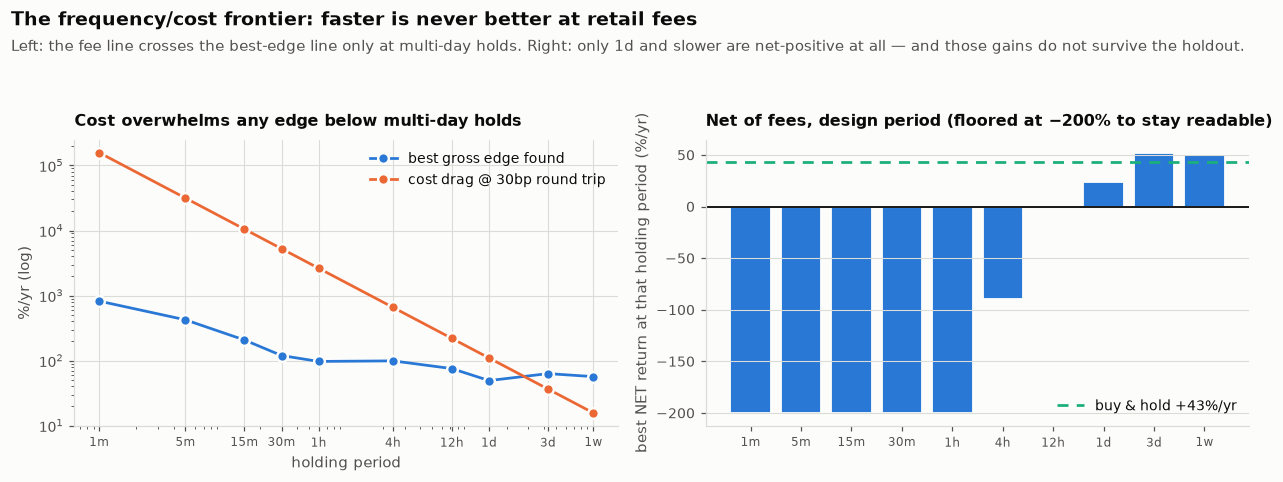

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))
hm = sorted(SW.hold_min.unique())
best_by_hold = SW.groupby("hold_min")["net_ann_%"].max().reindex(hm)
gross_by_hold = SW.groupby("hold_min")["gross_ann_%"].max().reindex(hm)
drag = [MIN_PER_YEAR / h * COST_BPS / 1e4 * 100 for h in hm]
axes[0].plot(hm, gross_by_hold, "o-", color=C1, ms=7, mec=SURFACE, mew=1.6,
             label="best gross edge found")
axes[0].plot(hm, drag, "o-", color=C2, ms=7, mec=SURFACE, mew=1.6,
             label=f"cost drag @ {COST_BPS:.0f}bp round trip")
axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set_xticks(hm, [HOLD_LABEL[h] for h in hm], fontsize=8)
axes[0].set_xlabel("holding period"); axes[0].set_ylabel("%/yr (log)")
axes[0].set_title("Cost overwhelms any edge below multi-day holds")
axes[0].legend(loc="upper right"); axes[0].set_axisbelow(True)

axes[1].bar([HOLD_LABEL[h] for h in hm], best_by_hold.clip(lower=-200), color=C1,
            edgecolor=SURFACE, linewidth=1.2)
axes[1].axhline(0, color=INK, lw=1.2)
axes[1].axhline(bh_d["ann_%"], color=C3, lw=1.8, ls=(0, (4, 3)),
                label=f"buy & hold {bh_d['ann_%']:+.0f}%/yr")
axes[1].set_ylabel("best NET return at that holding period (%/yr)")
axes[1].set_title("Net of fees, design period (floored at −200% to stay readable)")
axes[1].tick_params(axis="x", labelsize=8)
axes[1].legend(loc="lower right"); axes[1].grid(axis="x", visible=False)
figure_titles(fig, "The frequency/cost frontier: faster is never better at retail fees",
              "Left: the fee line crosses the best-edge line only at multi-day holds. Right: only 1d and slower are net-positive at all — and those gains do not survive the holdout.")
plt.show()

---
# VERDICT

In [10]:
W = 80
best_turn = top["turnover"] * (MIN_PER_YEAR / top["hold_min"])
F1 = bool((SW["net_ann_%"] > 0).any())
F5 = bool(best_turn < 200)
CRIT = [
    ("F1", "Something is net-positive in the design period", F1,
     f"{int((SW['net_ann_%'] > 0).sum())} of {len(SW)} combinations. Every single one is a "
     f"holding period of 1 DAY OR SLOWER, and every one is momentum. Nothing at 12 "
     f"hours or faster is net-positive at any lookback, in either direction. The "
     f"median across all 100 is {SW['net_ann_%'].median():+,.0f}%/yr."),
    ("F2", "Beats the bootstrap null", F2,
     f"No. The best net return is {ACT['max_net']:+.1f}%/yr; shuffling BTC's own minute "
     f"returns and re-running the same 60-combination sweep gives a median best of "
     f"{NULL['max_net'].median():+.1f}%/yr and a 95th percentile of {NULL['max_net'].quantile(0.95):+.1f}%/yr. "
     f"p = {float((NULL['max_net'] >= ACT['max_net']).mean()):.3f}. The apparent edge is inside what noise "
     f"produces across that many tries."),
    ("F3", "Survives the holdout", F3,
     f"No. The design-period best (momentum, 3-day hold) returns "
     f"{sel['net_ann_%_hold'].iloc[0]:+.1f}%/yr in 2024-2026. Only {int((SW_H['net_ann_%'] > 0).sum())} of 100 combinations are "
     f"net-positive out of sample. Note the ordering IS stable here (rank "
     f"correlation +0.83 on multi-day holds) - momentum reliably beats reversal - "
     f"but the level is not enough."),
    ("F4", "Beats simply holding BTC", F4,
     f"No, and not close. In the holdout the best rule in the entire grid managed "
     f"Sharpe {best_h['sharpe_net']:.2f} against buy-and-hold's {bh_h['sharpe']:.2f}, and "
     f"{best_h['net_ann_%']:+.1f}%/yr against {bh_h['ann_%']:+.1f}%/yr. Every rule tested "
     f"underperformed doing nothing. ON ETH THE SAME RULE PASSED - "
     f"{e_sel['net_ann_%']:+.1f}%/yr against buy-and-hold's {bh_e_h['ann_%']:+.1f}%/yr - which is "
     f"discussed below rather than averaged away."),
    ("F5", "Executable by hand at €1,000", F5,
     f"Yes, but only for the combinations that fail everything else. The best rule "
     f"trades about {best_turn:.0f} times a year - perfectly manageable. The fast rules that "
     f"would need automation are exactly the ones arithmetic already excluded."),
]
n_ok = sum(c[2] for c in CRIT)
print("=" * W)
print("FASTER IS NEVER BETTER".center(W))
print("=" * W)
print()
for cid, desc, ok, detail in CRIT:
    print(f"{cid}  [{'PASS' if ok else 'FAIL'}]  {desc}")
    for line in __import__("textwrap").wrap(detail, W - 6):
        print(f"      {line}")
    print()
print("-" * W)
print(f"{n_ok} of {len(CRIT)} criteria met.")
print("-" * W)
print(f"""
THE ANSWER TO THE QUESTION ASKED
{'-'*W}
  "At what holding period does fee drag stop eating everything?"

  Somewhere between 12 hours and 1 day - and that is the FLOOR, not a
  recommendation. Below it nothing is net-positive at any lookback or direction.
  Above it, the surviving strategies are the multi-day momentum rules that
  notebooks 2 and 5 already tested at daily frequency and already rejected.

  So intraday adds nothing. The profitable region begins exactly where the
  earlier work was already operating, and everything faster is excluded by
  arithmetic before any question of skill arises. At a 30bp round trip, flipping
  hourly costs {MIN_PER_YEAR/60*COST_BPS/1e4*100:,.0f}%/yr and flipping every minute costs {MIN_PER_YEAR*COST_BPS/1e4*100:,.0f}%/yr.
  No edge in any asset class is that large.

  The one genuinely new thing worth keeping: the live order book showed a
  ONE-CENT spread on BTC with enough size to fill €1,000 outright. At your size
  slippage is not the enemy and never was. The enemy is the flat percentage fee,
  and the only defence against it is trading rarely.

THE SPLIT RESULT, NOT AVERAGED AWAY
{'-'*W}
  The same design-selected rule (3-day momentum) went {sel['net_ann_%_hold'].iloc[0]:+.1f}%/yr on BTC and
  {e_sel['net_ann_%']:+.1f}%/yr on ETH in the same holdout. One pass, one fail, on n = 2 assets.
  That is not evidence either way on its own - but the pattern is informative.

  ETH buy-and-hold managed {bh_e_h['ann_%']:+.1f}%/yr (Sharpe {bh_e_h['sharpe']:.2f}) in that window while BTC
  managed {bh_h['ann_%']:+.1f}%/yr (Sharpe {bh_h['sharpe']:.2f}). The trend rule beat the asset that went
  nowhere and lost to the asset that went up. That is precisely notebook 5's
  conclusion arriving again by a different route: trend is insurance, not alpha.
  It pays when the underlying disappoints and costs you when it does not, which
  is a risk-management property, not an edge - and it is why F2, the null, is
  the criterion that actually settles this. At p = {float((NULL['max_net'] >= ACT['max_net']).mean()):.2f}, the whole thing sits
  inside what shuffled data produces across 60 tries.
""")
print("=" * W)
print("BOTTOM LINE")
print("=" * W)
print(f"""  Seven notebooks. Trading faster does not help - it is arithmetically
  disqualified long before it is empirically disqualified. The best intraday
  rule found on 9.1 years and 4.75 million minute bars fails the null
  (p = {float((NULL['max_net'] >= ACT['max_net']).mean()):.2f}), fails the holdout, and loses to buy-and-hold.

  If you take one operational rule from all of this: every trade costs you
  roughly 0.3% and buys you nothing in expectation, so the correct trading
  frequency at €1,000 is close to zero. Whatever you decide to hold, hold it.""")
print("=" * W)

                             FASTER IS NEVER BETTER                             

F1  [PASS]  Something is net-positive in the design period
      10 of 100 combinations. Every single one is a holding period of 1 DAY OR
      SLOWER, and every one is momentum. Nothing at 12 hours or faster is net-
      positive at any lookback, in either direction. The median across all 100
      is -704%/yr.

F2  [FAIL]  Beats the bootstrap null
      No. The best net return is +52.3%/yr; shuffling BTC's own minute returns
      and re-running the same 60-combination sweep gives a median best of
      +41.2%/yr and a 95th percentile of +83.1%/yr. p = 0.303. The apparent edge
      is inside what noise produces across that many tries.

F3  [FAIL]  Survives the holdout
      No. The design-period best (momentum, 3-day hold) returns -1.5%/yr in
      2024-2026. Only 5 of 100 combinations are net-positive out of sample. Note
      the ordering IS stable here (rank correlation +0.83 on multi-day holds) -
